In [810]:
import pandas as pd
import numpy as np
import importlib
from tqdm import tqdm

import matplotlib.colors as mcolors
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


import plotly.express as px
from matplotlib.animation import FuncAnimation

import utility_functions as uf

In [811]:
df_cs_yearly = pd.read_csv(uf.PATH+"df_cs_yearly.csv", index_col = [0, 1, 2]).xs("individual", level=2)
df_prob_yearly = df_cs_yearly.div(df_cs_yearly.sum(axis=1), axis=0)

n_years = 5

df_cs_yearly = (
    df_cs_yearly
    .sort_index()
    .groupby(level=0)
    .rolling(n_years).sum()
    .reset_index(level=0, drop=True)
)
df_prob_yearly = df_cs_yearly.div(df_cs_yearly.sum(axis=1), axis=0)

df_dist_yearly = pd.read_csv(uf.PATH+"df_dist_w1_rolling_yearly_individual.csv", index_col=[0, 1])

In [812]:
import geopandas as gpd
import matplotlib.patches as mpatches

url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
world_url = gpd.read_file(url)

In [813]:
df_map_analysis = pd.read_csv(uf.PATH+"df_map_analysis.csv").dropna(subset="cluster")

In [814]:
df_map_analysis.dropna(subset="cluster")

,year,country,cluster
37,1975,AR,8.0
38,1975,AT,0.0
39,1975,AU,7.0
40,1975,BE,5.0
41,1975,BG,4.0
...,...,...,...
3890,2023,VN,12.0
3891,2023,YE,5.0
3892,2023,ZA,12.0
3893,2023,ZM,10.0


# Utilities

In [815]:
# df_baricenter_yearly_list = []

# year_list = df_map_analysis.year.drop_duplicates().sort_values().to_list()

# for year_loop in year_list:
#     country_list = df_map_analysis.query("year == @year_loop").country.to_list()
#     df_prob = df_prob_yearly.xs(year_loop, level=1).loc[country_list]
#     # print(df_prob["3002"])
#     df_baricenter_yearly_list.append(uf.get_w1_barycenter(df_prob).T.rename(columns={0: year_loop}))
    
# df_baricenter_global_yearly = pd.concat(df_baricenter_yearly_list, axis=1).T

In [1473]:
year_list = df_map_analysis.year.drop_duplicates().sort_values().to_list()

In [1474]:
# df_baricenter_global_yearly.to_csv(uf.PATH+"df_barycenter_global_yearly.csv")
df_baricenter_global_yearly = pd.read_csv(uf.PATH+"df_barycenter_global_yearly.csv", index_col=0)

In [1475]:
uf.plotly_heatmap(df_baricenter_global_yearly, df_baricenter_global_yearly.columns, df_baricenter_global_yearly.index,
                  colorscale="non", z_min=0, z_max=0.02, line_height=10, x_type="subfield")

In [1476]:
cluster_list = df_map_analysis.cluster.drop_duplicates().sort_values().to_list()
subfield_tree = uf.get_subfield_tree(uf.df_topics)

In [819]:
profile_yearly_list = []
for cluster_loop in cluster_list:
    cluster_year_list = df_map_analysis.query("cluster == @cluster_loop").year.drop_duplicates().sort_values().to_list()
    cluster_profile_yearly_list = []
    for year_loop in cluster_year_list:
        cluster_country_list = df_map_analysis.query("cluster == @cluster_loop and year == @year_loop").country.drop_duplicates().sort_values().to_list()
        if cluster_country_list == []:
            print(year_loop, cluster_loop)
            continue
        # print(cluster_country_list)
        df_prob = df_prob_yearly.xs(year_loop, level=1).loc[cluster_country_list]
        cluster_profile_yearly_list.append(uf.get_w1_barycenter(df_prob).T.rename(columns={0: year_loop}))
    # print(cluster_profile_yearly_list)
    if cluster_profile_yearly_list == []:
        print(year_loop, cluster_loop)
        continue
    profile_yearly_list.append(pd.concat(cluster_profile_yearly_list, axis=1).T.assign(cluster=cluster_loop))
df_profile_yearly = pd.concat(profile_yearly_list).reset_index(names="year").set_index(["cluster", "year"])

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1243: RuntimeWarning:

divide by zero encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1243: RuntimeWarning:

overflow encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1243: RuntimeWarning:

invalid value encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1286: RuntimeWarning:

divide by zero encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1286: RuntimeWarning:

overflow encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1286: RuntimeWarning:

invalid value encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/util

In [820]:
# df_profile_yearly.to_csv(uf.PATH+"df_profile_by_cluster.csv")
# df_profile_yearly = pd.read_csv(uf.PATH+"df_profile_by_cluster.csv", index_col=[0, 1])

In [1477]:
pivot = df_map_analysis.pivot(index="country", columns="year", values="cluster")
pivot

clusters = pivot.values

# Broadcasting comparison
same_cluster = clusters[:, None, :] == clusters[None, :, :]

# Count matches across years
co_membership = same_cluster.sum(axis=2)

# Convert back to dataframe
df_neighbours_counts = pd.DataFrame(
    co_membership,
    index=pivot.index,
    columns=pivot.index
)

# df_n_years = pd.DataFrame(
#     co_membership,
#     index=pivot.index,
#     columns=pivot.index
# )
# df_dist_clusters_yearly = 1 - df_n_years.div(np.diagonal(df_n_years.values))

# # df_dist_clusters_yearly.to_csv(uf.PATH+f"df_dist_countries_{param_value}_medoid_short_w1_{mode}.csv", index=True)

In [1478]:
df_stats_cluster = uf.get_cluster_stats(df_map_analysis, df_cs_yearly.reset_index(), df_dist_yearly.reset_index())
all_clusters = df_map_analysis.cluster.drop_duplicates().sort_values()

n_countries_global = df_map_analysis.groupby(["year"], as_index=True).country.nunique()
std = df_baricenter_global_yearly.std()


In [1479]:
# uf.plotly_heatmap(df_baricenter_global_yearly,
#                   x_labels=df_baricenter_global_yearly.columns,
#                   y_labels=df_baricenter_global_yearly.index,
#                   colorscale="non",
#                   z_min=0, z_max=0.02,
#                   line_height=10,
#                   x_type="subfield")

In [1480]:
# RED = "#4E0000"
# BLUE = "#13273F"
# YELLOW = "#CB8E16"


BLUE = "#8C9EFF"
# GREEN = "#D6F74C"
GREEN = "#285B23"
ORANGE = "#F06038"
BRONZE = "#FCD9BE"
PURPLE = "#6f2dbd"
ROSE = "#d1495b"

# BLUE = "#192741"
# GREEN = "#404322"
# ORANGE = "#AD4A18"
# BRONZE = "#CE8A39"

BLUE_DARK = "#193254"
GREEN_DARK = "#35521C"
ORANGE_DARK = "#943D14"
BRONZE_DARK = "#E39F3D"

BLUE_LIGHT = "#0D1AA8"
GREEN_LIGHT = "#404322"
ORANGE_LIGHT = "#AD4A18"
BRONZE_LIGHT = "#CE8A39"

colors_domain = {
    "Physical Sciences": ORANGE,
    "Social Sciences": PURPLE,
    "Health Sciences": BLUE,
    "Life Sciences": GREEN
    # "Physical Sciences": [ORANGE_LIGHT, ORANGE_DARK],
    # "Social Sciences": [BLUE_LIGHT, BLUE_DARK],
    # "Health Sciences": [GREEN_LIGHT, GREEN_DARK],
    # "Life Sciences": [BRONZE_LIGHT, BRONZE_DARK]
}

In [1481]:
def white_to_color(color, n=256):
    return mcolors.LinearSegmentedColormap.from_list(
        f"white_to_{color}",
        ["white", color],
        N=n
    )

def from_color_list(color_list, n=256):
    return mcolors.LinearSegmentedColormap.from_list(
        f"from_list",
        color_list,
        N=n
    )

def truncate_cmap(cmap, minval=0.3, maxval=1.0, n=256):
    return mcolors.LinearSegmentedColormap.from_list(
        f"trunc_{cmap.name}",
        cmap(np.linspace(minval, maxval, n))
    )


In [1482]:
def get_spec(cluster, df_map_analysis, std, df_baricenter_global_yearly):
    years_list = df_map_analysis.query("cluster == @cluster").year.drop_duplicates().sort_values().to_list()
    n_countries_global = df_map_analysis.groupby(["year"], as_index=True).country.nunique()

    n_countries_cluster = df_map_analysis.query("cluster == @cluster").drop(columns="cluster").groupby(["year"], as_index=True).nunique().country
    mult = 1 / np.sqrt(
        pd.DataFrame((std ** 2).to_frame("std_global").T.values / n_countries_cluster.to_frame("a").values, index=n_countries_cluster.index, columns=std.index)
        .mul((n_countries_global - n_countries_cluster) / (n_countries_global - 1), axis=0)).dropna(how="all")

    return (
        df_profile_yearly
        .xs(cluster, level=0)
        .sub(df_baricenter_global_yearly.loc[years_list])
        .mul(mult.loc[years_list])
    )
    # return (
    #     df_profile_yearly
    #     .xs(cluster, level=0)
    #     .sub(df_baricenter_global_yearly.loc[years_list])
    # )

In [1483]:
def get_prob_fields(df_prob):
    return (
        df_prob
        .T
        .merge(uf.df_topics[["subfield_id", "field_name", "domain_id"]].drop_duplicates().assign(subfield_str=lambda df: df.subfield_id.astype(str)),
            left_index=True, right_on="subfield_str", how="left")
        .drop(columns=["subfield_str", "subfield_id"])
        .groupby(["domain_id", "field_name"], as_index=False)
        .sum()
        .sort_values(["domain_id", "field_name"])
        .drop(columns="domain_id")
        .set_index("field_name")
        .T
    )

In [1484]:
def get_spec_fields(cluster, df_map_analysis, std, df_baricenter_global_yearly):
    years_list = df_map_analysis.query("cluster == @cluster").year.drop_duplicates().sort_values().to_list()
    n_countries_global = df_map_analysis.groupby(["year"], as_index=True).country.nunique()

    df_profile_fields = get_prob_fields(df_profile_yearly.xs(cluster, level=0))
    df_global_profile_fields = get_prob_fields(df_baricenter_global_yearly)
    std_fields = df_global_profile_fields.std()

    n_countries_cluster = df_map_analysis.query("cluster == @cluster").drop(columns="cluster").groupby(["year"], as_index=True).nunique().country
    mult = 1 / np.sqrt(
        pd.DataFrame((std_fields ** 2).to_frame("std_global").T.values / n_countries_cluster.to_frame("a").values, index=n_countries_cluster.index, columns=std_fields.index)
        .mul((n_countries_global - n_countries_cluster) / (n_countries_global - 1), axis=0)).dropna(how="all")

    return (
        df_profile_fields
        .sub(df_global_profile_fields.loc[years_list])
        .mul(mult.loc[years_list])
    )
    # return (
    #     df_profile_fields
    #     .sub(df_global_profile_fields.loc[years_list])
    # )

In [1485]:
df_profile_spec_yearly_list = []
for cluster_loop in all_clusters:
    df_profile_spec_yearly_list.append(get_spec(cluster_loop, df_map_analysis, std, df_baricenter_global_yearly).reset_index().assign(cluster=cluster_loop))
df_profile_spec_yearly = pd.concat(df_profile_spec_yearly_list).set_index(["cluster", "year"])

In [1486]:
df_profile_spec_fields_yearly_list = []
for cluster_loop in all_clusters:
    # print(cluster_loop)
    df_profile_spec_fields_yearly_list.append(get_spec_fields(cluster_loop, df_map_analysis, std, df_baricenter_global_yearly).reset_index(names="year").assign(cluster=cluster_loop))
df_profile_spec_fields_yearly = pd.concat(df_profile_spec_fields_yearly_list).set_index(["cluster", "year"])

In [1487]:
df_profile_norm_spec_fields_yearly_list = []
for year_loop in year_list:    
    df_profile_norm_spec_fields_yearly_list.append(
        df_profile_spec_fields_yearly.xs(year_loop, level=1)
        .div(df_profile_spec_fields_yearly.xs(year_loop, level=1).abs().sum())
        .assign(year=year_loop)
    )
df_profile_norm_spec_fields_yearly = pd.concat(df_profile_norm_spec_fields_yearly_list).reset_index().set_index(["cluster", "year"])

In [831]:
df_dist_country_cluster_raw_list = []
for year_loop in df_map_analysis.year.drop_duplicates().sort_values():
    df1 = df_prob_yearly.xs(year_loop, level=1)
    df2 = df_profile_yearly.xs(year_loop, level=1)

    df_dist_country_cluster_raw_list.append(uf.get_w1_distances_matrix(df1, df2)
                                            .reset_index(names="country")
                                            .melt(id_vars="country", var_name="cluster")
                                            .assign(year=year_loop)
                                            )
df_dist_country_cluster_raw = pd.concat(df_dist_country_cluster_raw_list)

df_dist_country_cluster = (
    df_dist_country_cluster_raw
    .assign(cluster_int=lambda df: df.cluster.astype(float))
    .drop(columns="cluster")
    .rename(columns={"cluster_int": "cluster"})
    .merge(df_map_analysis, on=["country", "year"], how="right", suffixes=["_dist", "_map"])
    .assign(in_cluster=lambda df: (df.cluster_dist == df.cluster_map).astype(int))
    # .groupby("cluster").value.mean()
)

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1243: RuntimeWarning:

divide by zero encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1243: RuntimeWarning:

overflow encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1243: RuntimeWarning:

invalid value encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1359: RuntimeWarning:

divide by zero encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1359: RuntimeWarning:

overflow encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1359: RuntimeWarning:

invalid value encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/util

# Overview

In [1488]:
uf.plotly_heatmap(df_baricenter_global_yearly, df_baricenter_global_yearly.columns, df_baricenter_global_yearly.index,
                  colorscale="non", z_min=0, z_max=0.05, line_height=10, x_type="subfield", title="Global barycenter profile")

In [1686]:
cluster_spec_list = []
for cluster_loop in all_clusters:
    if cluster_loop == 0:
        continue
    years_list = df_map_analysis.query("cluster == @cluster_loop").year.drop_duplicates().sort_values().to_list()

    # n_countries_cluster = df_map_analysis.query("cluster == @cluster_loop").drop(columns="cluster").groupby(["year"], as_index=True).nunique().country
    # mult = 1 / np.sqrt(
    #     pd.DataFrame((std ** 2).to_frame("std_global").T.values / n_countries_cluster.to_frame("a").values, index=n_countries_cluster.index, columns=std.index)
    #     .mul((n_countries_global - n_countries_cluster) / (n_countries_global - 1), axis=0)).dropna(how="all")

    # display(df_profile_norm_spec_fields_yearly.xs(cluster_loop).T)
    tmp_dict = (
        df_profile_norm_spec_fields_yearly.xs(cluster_loop).T
        .mean(axis=1)
        .to_frame("median_spec")
        .merge(uf.df_topics[["field_name", "domain_name"]].drop_duplicates(),
            left_index=True, right_on="field_name")
        # .groupby(["field_name", "domain_name"], as_index=False)
        .groupby(["domain_name"], as_index=False)
        .median_spec
        .sum()
        .sort_values("median_spec")
        # .assign(median_spec_norm = lambda df: df.median_spec / df.median_spec.abs().sum())
        .iloc[-1]
        .to_dict()
    )

    tmp_dict["cluster"] = cluster_loop
    cluster_spec_list.append(tmp_dict)
    if tmp_dict["median_spec"] == 0:
        print("NAN")
        display(
            df_profile_yearly
            .xs(cluster_loop, level=0)
        )

df_cluster_spec = pd.json_normalize(cluster_spec_list).sort_values(["domain_name", "median_spec"])

min_median = df_cluster_spec.median_spec.min()
max_median = df_cluster_spec.median_spec.max()

In [1687]:
df_cluster_spec

,domain_name,median_spec,cluster
3,Health Sciences,1.053521,7.0
4,Health Sciences,1.763618,8.0
0,Physical Sciences,0.290025,2.0
8,Physical Sciences,0.807430,12.0
5,Physical Sciences,1.426425,9.0
1,Physical Sciences,1.649991,4.0
2,Physical Sciences,2.346021,5.0
6,Social Sciences,0.976734,10.0
7,Social Sciences,1.150696,11.0


In [1707]:
domain_list = df_cluster_spec.domain_name.unique()

color_dict_cluster = {
    -1: "white",
    0: "grey",
}

for domain_loop in domain_list:
    # cmap = from_color_list(colors_domain[domain_loop])
    cmap = white_to_color(colors_domain[domain_loop])
    cmap = truncate_cmap(cmap, 0.1, 1.0)

    cluster_list = df_cluster_spec.query("domain_name == @domain_loop").cluster.to_list()

    # print(domain_loop, cluster_list)

    if len(cluster_list) == 1:
        color_list = [cmap(1.0)]
        # print(color_list)
    else:
        intensity = np.array([(val - min_median) / (max_median - min_median) for val in df_cluster_spec.query("domain_name == @domain_loop").median_spec])
        color_list = cmap(intensity)
    color_list = cmap(np.linspace(0.2, 1, len(cluster_list)))
    for i, cluster in enumerate(cluster_list):
        color_dict_cluster[cluster] = color_list[i]

In [1708]:
# color_dict_cluster = {
#     2: "#efb366", 4: "#8ab17d", 5: "#2a9d8f", 7: "#287271", 8: "#264653", 9: "#e9c46a", 10: "#ee8959", 11: "#f4a261", 12: "#e76f51",
#     -1: "white", 0: "grey"
# }

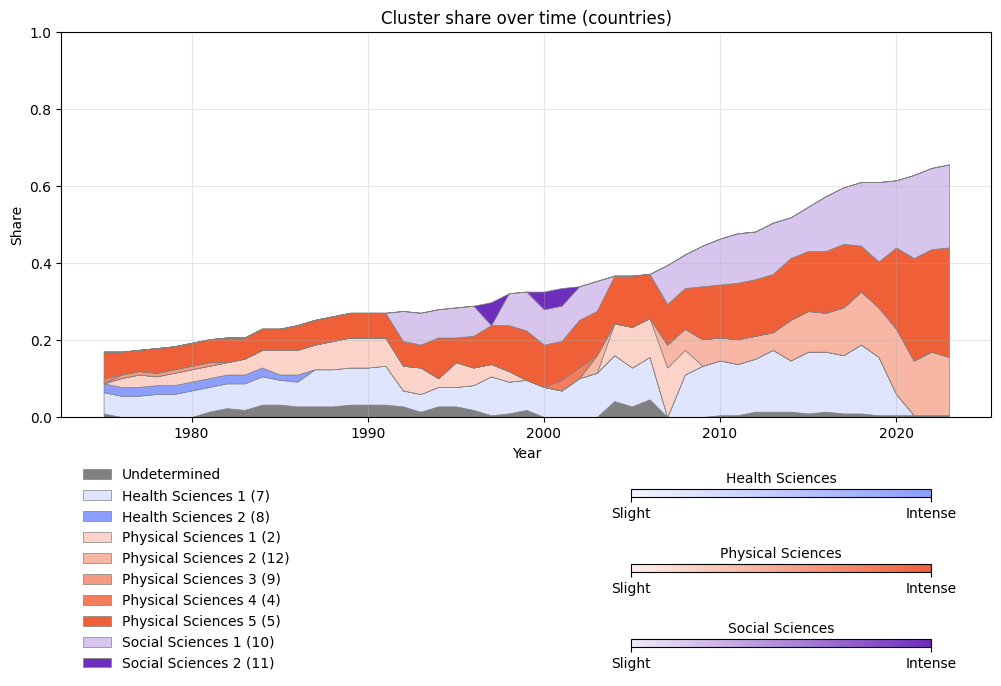

In [1709]:
names_dict_cluster = {
    -1: "Not analysed",
    0: "Undetermined",
}

count_dict = {}
for cluster_loop in df_cluster_spec.cluster:
    # print(cluster_loop)
    # name = df_cluster_spec.query("cluster == @cluster_loop").iloc[0].field_name
    name = df_cluster_spec.query("cluster == @cluster_loop").iloc[0].domain_name
    if not (name in count_dict.keys()):
        count_dict[name] = 1
    else:
        count_dict[name] += 1
    names_dict_cluster[cluster_loop] = name+" "+str(count_dict[name])+f" ({int(cluster_loop)})"

df_stats_cluster["cluster"] = df_stats_cluster["cluster"].astype(int)

# --- 3. Add cluster names ---
df_plot = df_stats_cluster.copy()
df_plot["cluster_name"] = df_plot["cluster"].map(names_dict_cluster)
df_plot["cluster_name"] = df_plot["cluster_name"].fillna("Undefined")

# --- 4. Build color map with names ---
color_map_named = {
    names_dict_cluster[k]: color_dict_cluster[k]
    for k in color_dict_cluster
}
color_map_named["Undefined"] = "lightgrey"

# --- 5. Pivot to wide format ---
df_wide = (
    df_plot
    .pivot(index="year", columns="cluster_name", values="countries_share")
    .fillna(0)
)

# --- 6. Define consistent order ---
cluster_order = list(names_dict_cluster.values())

# keep only existing columns
cluster_order = [c for c in cluster_order if c in df_wide.columns]

df_wide = df_wide[cluster_order]

# --- 7. Plot stacked area ---
fig, ax = plt.subplots(figsize=(12, 5))

polys = ax.stackplot(
    df_wide.index,
    df_wide.T.values,
    labels=df_wide.columns,
    colors=[color_map_named[c] for c in df_wide.columns],
    edgecolor="grey",
)
for poly in polys:
    poly.set_linewidth(0.5)

# --- 8. Styling ---
ax.set_ylim(0, 1)
ax.set_xlabel("Year")
ax.set_ylabel("Share")
ax.set_title("Cluster share over time (countries)")

ax.legend(loc="upper left", bbox_to_anchor=(0.01, -0.1), frameon=False)
ax.grid(alpha=0.3)

# define normalization (same scale for all if needed)
norm = mpl.colors.Normalize(vmin=0, vmax=1)

# create mappables
domain_list = df_cluster_spec.domain_name.unique()
for i, domain in enumerate(domain_list):
    j = i // 2
    k = i % 2
    sm = mpl.cm.ScalarMappable(cmap=truncate_cmap(white_to_color(colors_domain[domain]), 0.1, 1.0), norm=norm)
    # sm = mpl.cm.ScalarMappable(cmap=truncate_cmap(from_color_list(colors_domain[domain]), 0.2, 1.0), norm=norm)
    sm.set_array([])
    cax = fig.add_axes([0.6, -0.05 - 0.15 * i, 0.25, 0.015])
    cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
    cbar.ax.xaxis.set_label_position('top')
    cbar.set_label(domain, labelpad=5)
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels(["Slight", "Intense"])


# plt.tight_layout()
plt.show()

In [1710]:
# df_plot_appearance = (
#     df_map_analysis
#     .groupby("country")
#     .year.min().to_frame("first_year")
#     .reset_index()
#     .merge(df_map_analysis, left_on=["country", "first_year"], right_on=["country", "year"])
#     .groupby(["cluster", "year"], as_index=False)
#     .country
#     .count()
#     .assign(country_cumsum=lambda df: df.groupby(["cluster"]).country.transform(lambda x: x.cumsum()))
# )

# # --- 1. Ensure clusters are integers ---
# df_stats_cluster["cluster"] = df_stats_cluster["cluster"].astype(int)

# # --- 3. Add cluster names ---
# df_plot = df_plot_appearance.query("year > 1975").copy()
# df_plot["cluster_name"] = df_plot["cluster"].map(names_dict_cluster)
# df_plot["cluster_name"] = df_plot["cluster_name"].fillna("Undefined")

# # --- 4. Build color map with names ---
# color_map_named = {
#     names_dict_cluster[k]: color_dict_cluster[k]
#     for k in color_dict_cluster
# }
# color_map_named["Undefined"] = "lightgrey"

# # --- 5. Pivot to wide format ---
# df_wide = (
#     df_plot
#     .pivot(index="year", columns="cluster_name", values="country")
#     .fillna(0)
# )

# # --- 6. Define consistent order ---
# cluster_order = list(names_dict_cluster.values())

# # keep only existing columns
# cluster_order = [c for c in cluster_order if c in df_wide.columns]

# df_wide = df_wide[cluster_order]

# # --- 7. Plot stacked area ---
# fig, ax = plt.subplots(figsize=(10, 5))

# ax.stackplot(
#     df_wide.index,
#     df_wide.T.values,
#     labels=df_wide.columns,
#     colors=[color_map_named[c] for c in df_wide.columns],
#     # edgecolor="grey",
# )
# # for poly in polys:
# #     poly.set_linewidth(0.5)
# # --- 8. Styling ---
# # ax.set_ylim(0, 1)
# ax.set_xlabel("Year")
# ax.set_ylabel("N_countries")
# ax.set_title("New countries by clusters")

# ax.legend(title="Cluster", loc="upper left", bbox_to_anchor=(1, 1))
# ax.grid(alpha=0.3)

# # define normalization (same scale for all if needed)
# norm = mpl.colors.Normalize(vmin=0, vmax=1)

# # create mappables
# domain_list = df_cluster_spec.domain_name.unique()
# for i, domain in enumerate(domain_list):
#     j = i // 2
#     k = i % 2
#     sm = mpl.cm.ScalarMappable(cmap=truncate_cmap(white_to_color(colors_domain[domain]), 0.1, 1.0), norm=norm)
#     # sm = mpl.cm.ScalarMappable(cmap=truncate_cmap(from_color_list(colors_domain[domain]), 0.2, 1.0), norm=norm)
#     sm.set_array([])
#     cax = fig.add_axes([0.2 + 0.1 * k + 0.25 * k, -0.02 - 0.15 * j, 0.25, 0.015])
#     cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
#     cbar.set_label(domain)
#     cbar.set_ticks([0, 1])
#     cbar.set_ticklabels(["Slight", "Intense"])

# # plt.tight_layout()
# plt.show()

/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_9860/2409604422.py:66: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



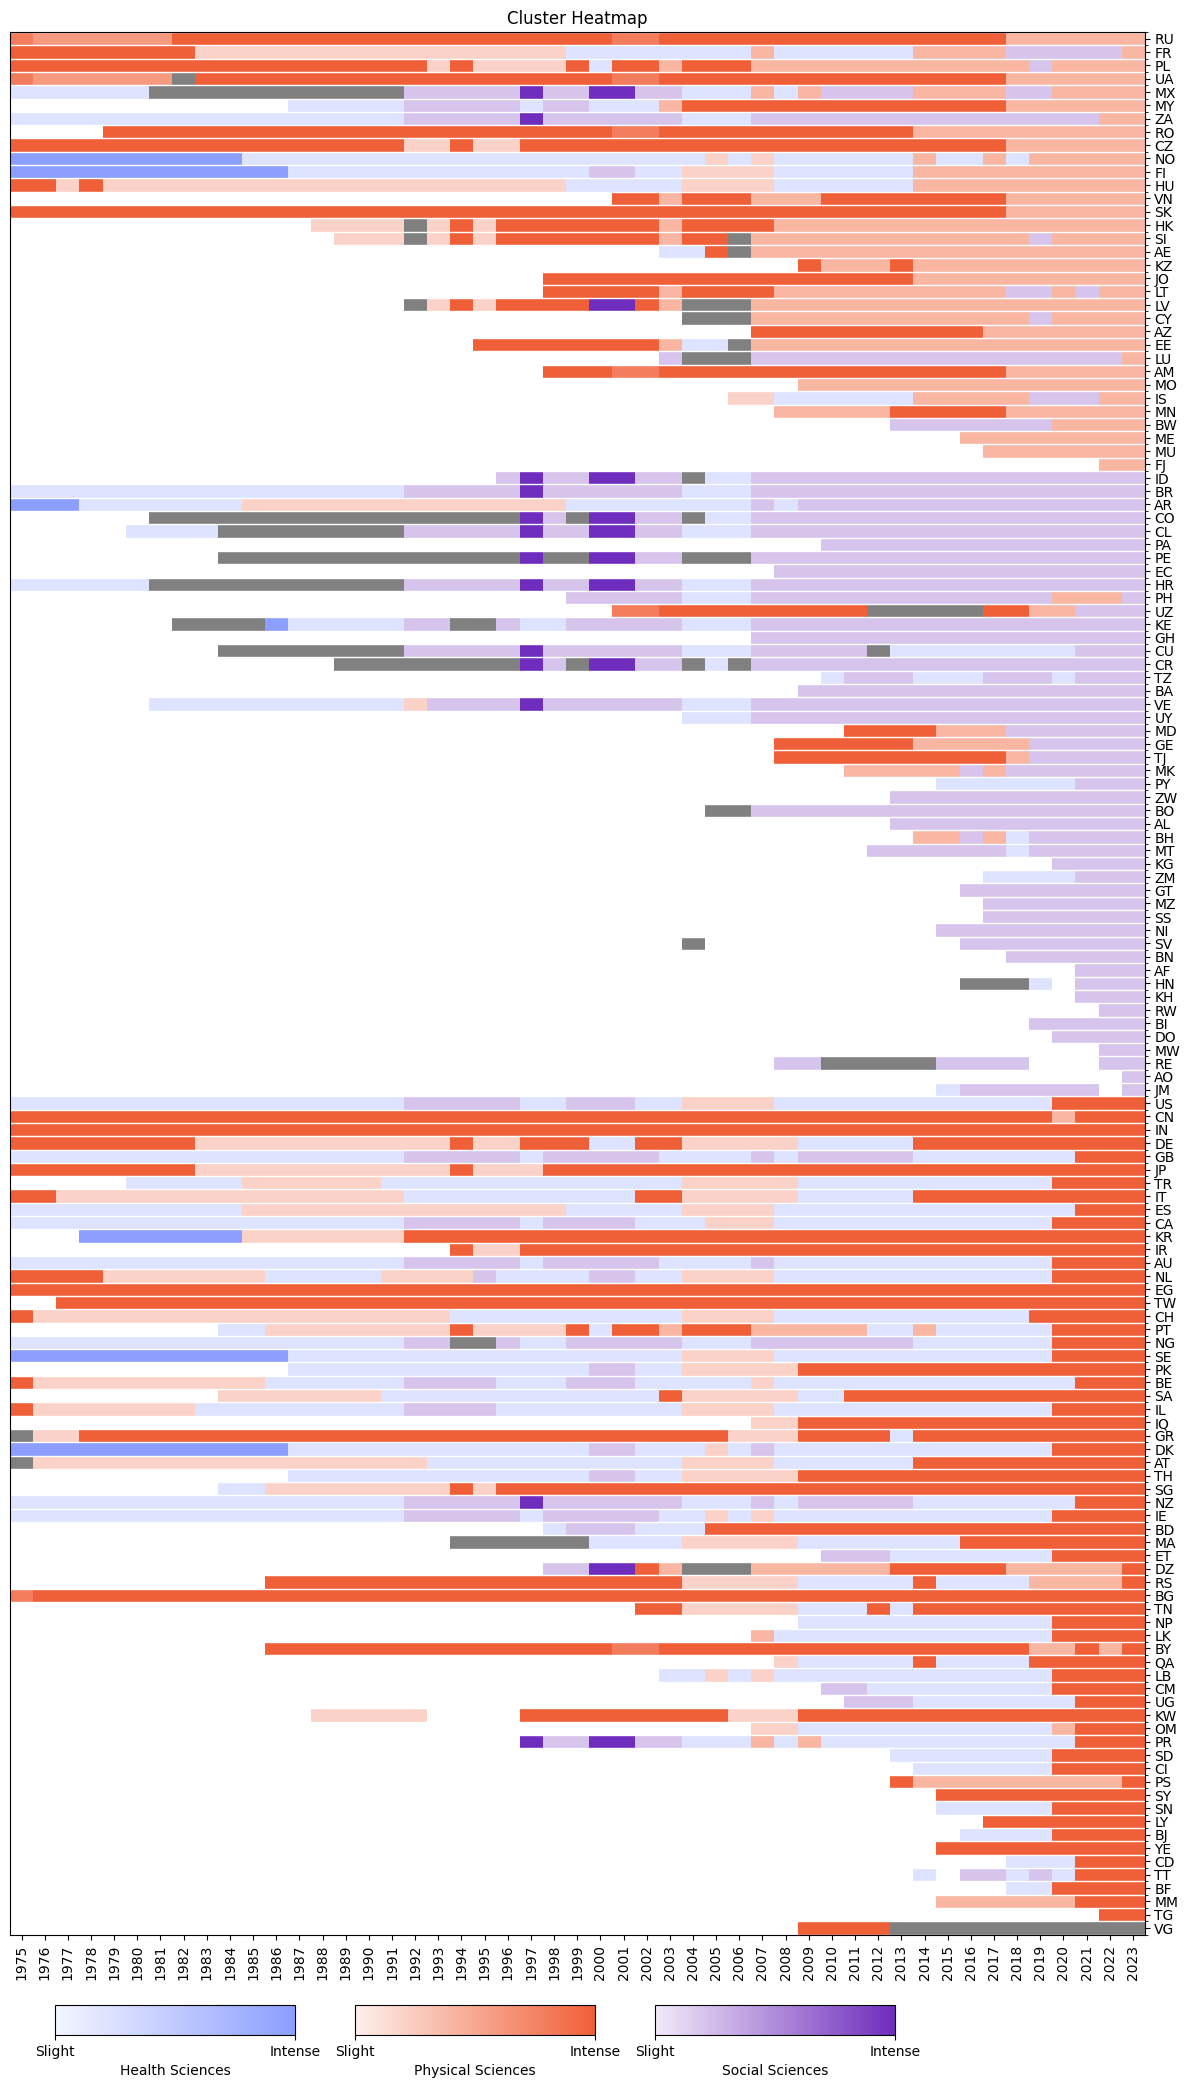

In [1711]:
year = 2023
y_label = (
    df_map_analysis
    .merge(df_cs_yearly.sum(axis=1).to_frame("total"), left_on=["country", "year"], right_index=True)
    .query("year == @year").sort_values(["cluster", "total"], ascending=False)
    .country
    .to_list()
)

df_plot = (
    df_map_analysis
    .pivot(index="country", columns="year", values="cluster")
    .loc[y_label]
)
# --- 1. Map clusters to indices ---
clusters = sorted(color_dict_cluster.keys())
clusters_with_missing = clusters

color_list = [color_dict_cluster[cl] for cl in clusters_with_missing]
cmap = mcolors.ListedColormap(color_list)

# --- 5. Plot heatmap ---
fig, ax = plt.subplots(figsize=(12, 20))

cluster_to_idx = {c: i for i, c in enumerate(clusters)}

im = ax.imshow(
    df_plot.fillna(-1).replace(cluster_to_idx).values,
    aspect="auto",
    cmap=cmap,
)

# --- 6. Axis labels ---
ax.set_xticks(range(len(df_plot.columns)))
ax.set_xticklabels(df_plot.columns, rotation=90)

ax.set_yticks(range(len(df_plot.index)))
ax.set_yticklabels(df_plot.index)

ax.set_title("Cluster Heatmap")


ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")

n_rows, n_cols = df_plot.shape
ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
ax.grid(which="minor", axis="y", color="white", linewidth=1)
ax.tick_params(which="minor", left=False)

# define normalization (same scale for all if needed)
norm = mpl.colors.Normalize(vmin=0, vmax=1)

# create mappables
domain_list = df_cluster_spec.domain_name.unique()
for i, domain in enumerate(domain_list):
    sm = mpl.cm.ScalarMappable(cmap=truncate_cmap(white_to_color(colors_domain[domain]), 0.1, 1.0), norm=norm)
    # sm = mpl.cm.ScalarMappable(cmap=truncate_cmap(white_to_color(colors_domain[domain]), 0.2, 1.0), norm=norm)
    sm.set_array([])
    cax = fig.add_axes([0.05 + 0.05 * i + 0.2 * i, -0.02, 0.2, 0.015])
    cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
    cbar.set_label(domain)
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels(["Slight", "Intense"])

plt.tight_layout()
plt.show()

# Year 

In [1712]:
year = 2001

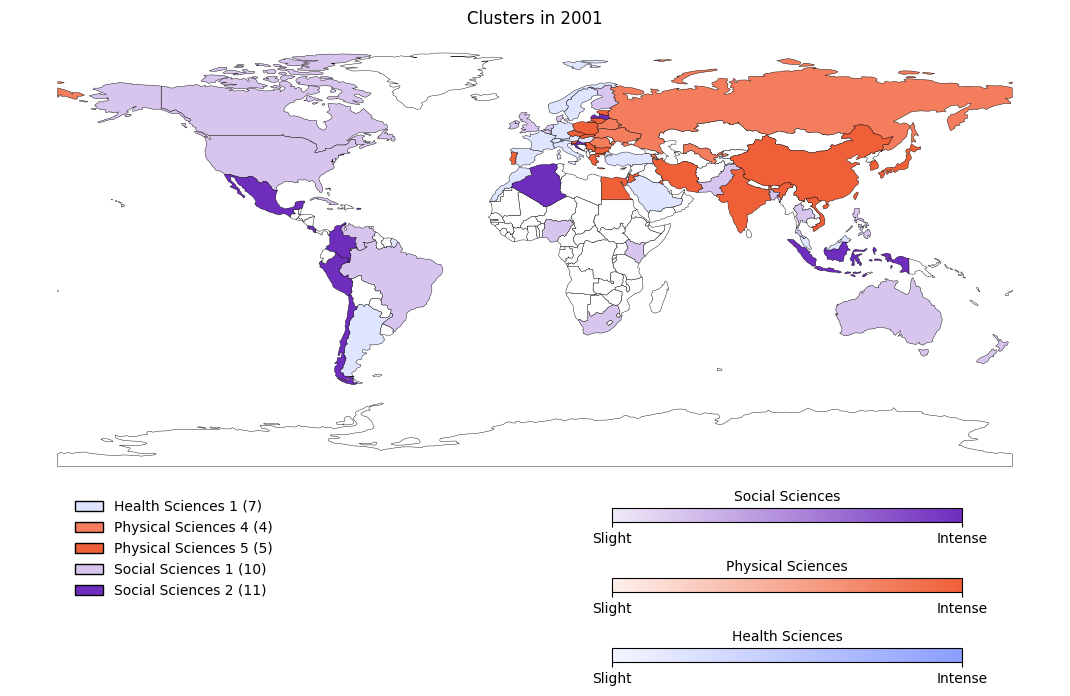

In [1713]:
# map with clusters
# --- 4. Merge with world map ---
world = world_url.merge(
    df_map_analysis.query("year == @year").merge(uf.df_country[["alpha-2", "alpha-3"]], left_on="country", right_on="alpha-2"),
    left_on="ISO_A3_EH",
    right_on="alpha-3",
    how="left"
)

# --- 5. Map cluster → color ---
world["color"] = world["cluster"].map(color_dict_cluster)

# fallback for missing
world["color"] = world["color"].fillna("white")

legend_elements = []
for cluster, color in color_dict_cluster.items():
    if cluster in df_map_analysis.query("year == @year").cluster.to_list():
        label = names_dict_cluster.get(cluster, str(cluster))
        
        legend_elements.append(
            Patch(facecolor=color, edgecolor="black", label=label)
        )

fig, ax = plt.subplots(figsize=(14, 7))
fig.set_constrained_layout(False)

fig.subplots_adjust(left=0.05, right=0.8, top=0.9, bottom=0.25)

world.plot(
    color=world["color"],
    edgecolor="black",
    linewidth=0.3,
    ax=ax
)

ax.set_axis_off()
ax.set_title(f"Clusters in {year}")
ax.set_aspect('auto')

# --- legend ---
ax.legend(
    handles=legend_elements,
    # title="Cluster",
    loc="upper left",
    bbox_to_anchor=(0.05, 0),
    frameon=False
)

# --- colorbars ---
for i, domain in enumerate(domain_list):
    j = i // 2
    k = i % 2
    # cax = fig.add_axes([0.15 + 0.35 * k, 0.05 + 0.08 * j, 0.25, 0.02])
    cax = fig.add_axes([0.48, 0 + 0.1 * i, 0.25, 0.02])

    sm = mpl.cm.ScalarMappable(
        cmap=truncate_cmap(white_to_color(colors_domain[domain]), 0.1, 1.0),
        norm=norm
    )
    sm.set_array([])

    cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
    cbar.ax.xaxis.set_label_position('top')
    cbar.set_label(domain, labelpad=5)
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels(["Slight", "Intense"])

plt.show()

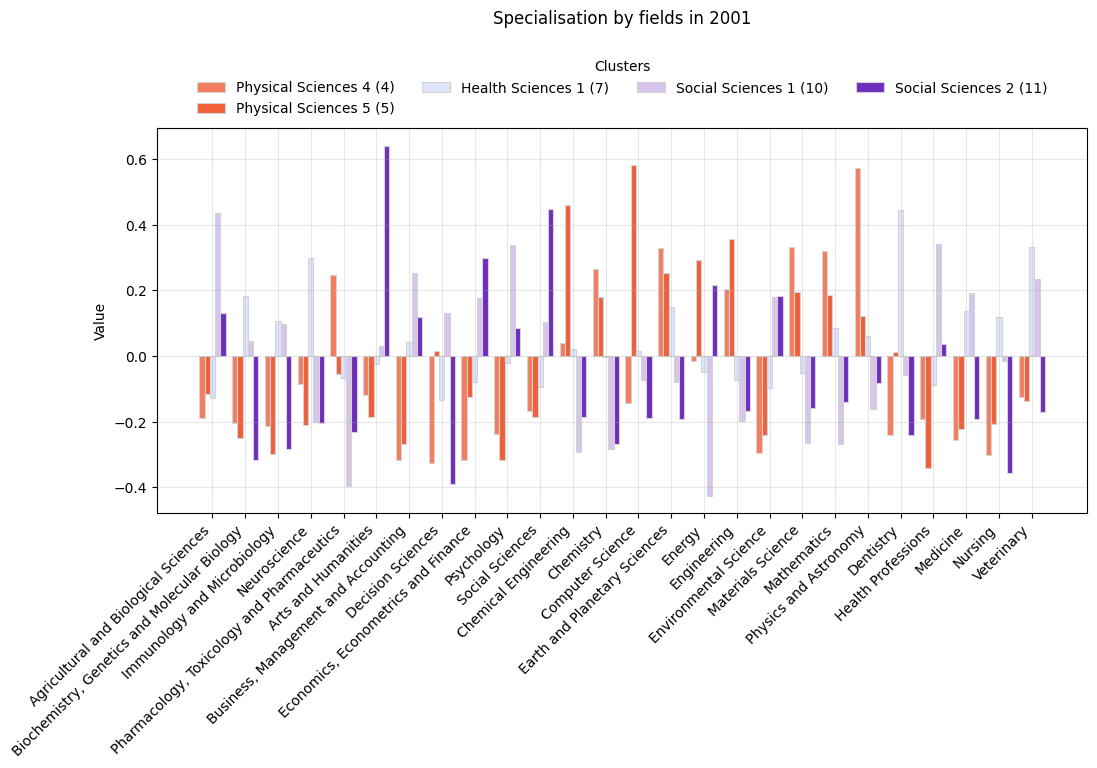

In [1714]:
df_plot = (
    df_profile_norm_spec_fields_yearly.xs(year, level=1).reset_index()
    .melt(id_vars=["cluster"], var_name="field_name",).query("(cluster != 0) and (field_name != \"year\")")
)

clusters = sorted(df_plot["cluster"].unique())
fields = df_plot["field_name"].unique()

x = np.arange(len(fields))
width = 0.8 / len(clusters)  # total width split across clusters

fig, ax = plt.subplots(figsize=(12, 5))

for i, cluster in enumerate(clusters):
    df_sub = df_plot[df_plot["cluster"] == cluster]
    
    # ensure correct order of fields
    df_sub = df_sub.set_index("field_name").reindex(fields)

    ax.bar(
        x + i * width,
        df_sub["value"],
        width=width,
        label=names_dict_cluster[cluster],
        color=color_dict_cluster.get(cluster, "grey"),
        edgecolor="lightgrey",     # 👈 border color
        linewidth=0.8         # 👈 border thickness
    )

# --- formatting ---
ax.set_xticks(x + width * (len(clusters)-1)/2)
ax.set_xticklabels(fields, rotation=45, ha="right")

ax.set_ylabel("Value")

n_rows = (len(clusters)-1) // 4

ax.legend(title="Clusters",
          loc="lower center",
          bbox_to_anchor=(0.5, 1),
          ncol=4,
          frameon=False)   # push outside to the right)
ax.grid( alpha=0.3)
ax.set_title(f"Specialisation by fields in {year}", y=1.15+0.1*(n_rows))

# plt.tight_layout()
plt.show()

In [1715]:
def plot_boxplot(ax, df, cluster_col, y_col, title):
    clusters = sorted(df[cluster_col].unique())

    data = [
        df[df[cluster_col] == c][y_col].values
        for c in clusters
    ]

    colors = [color_dict_cluster[cl] for cl in clusters]

    bp = ax.boxplot(
        data,
        patch_artist=True,
        tick_labels=clusters
    )

    # style boxes
    for box, color in zip(bp["boxes"], colors):
        box.set_facecolor(color)
        box.set_edgecolor("black")
        box.set_linewidth(1)

    # medians
    for median in bp["medians"]:
        median.set_color("black")
        median.set_linewidth(1.5)

    # whiskers & caps
    for whisker in bp["whiskers"]:
        whisker.set_color("black")

    for cap in bp["caps"]:
        cap.set_color("black")

    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)

In [1716]:
df1 = df_dist_country_cluster.query(
    "(year == @year) and (cluster_dist != 0) and (in_cluster == 1)"
)

df2 = (
    df_cs_yearly
    .sum(axis=1)
    .to_frame("total")
    .query("total > 0")
    .assign(log_total=lambda df: np.log(df.total))
    .merge(df_map_analysis, left_index=True, right_on=["country", "year"])
    .query("(year == @year) and (cluster != 0)")
)

df3 = (
    df_prob_yearly.fillna(0)
    .apply(uf.gini, axis=1)
    .to_frame("gini_country")
    .merge(df_map_analysis, left_index=True, right_on=["country", "year"])
    .query("(year == @year) and (cluster != 0)")
)

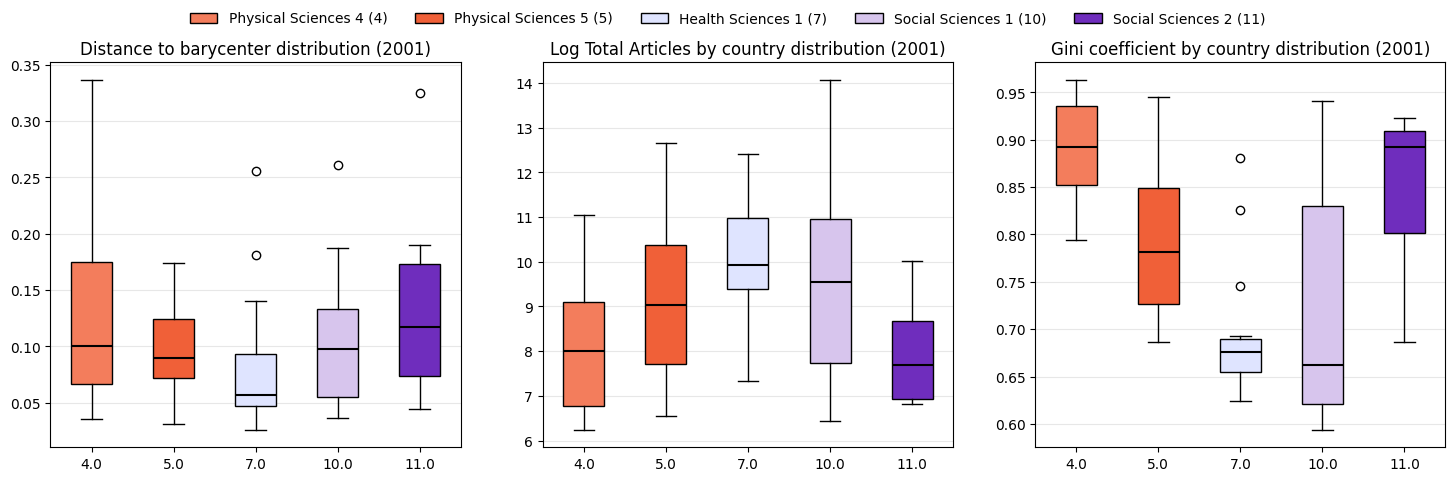

In [1717]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

plot_boxplot(
    axes[0],
    df1,
    cluster_col="cluster_dist",
    y_col="value",
    title=f"Distance to barycenter distribution ({year})"
)

plot_boxplot(
    axes[1],
    df2,
    cluster_col="cluster",
    y_col="log_total",
    title=f"Log Total Articles by country distribution ({year})"
)

plot_boxplot(
    axes[2],
    df3,
    cluster_col="cluster",
    y_col="gini_country",
    title=f"Gini coefficient by country distribution ({year})"
)

from matplotlib.patches import Patch

legend_handles = [
    Patch(facecolor=color_dict_cluster[cl], edgecolor="black",
          label=names_dict_cluster[cl])
    for cl in df_map_analysis.query("year == @year").cluster.drop_duplicates().sort_values().to_list()
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=len(legend_handles),
    frameon=False,
)

# plt.tight_layout(rect=[0, 0, 1, 0.9])  # leave space for legend
plt.show()

# Cluster overview

In [1718]:
cluster = 5
# 5, 14, 18

In [1719]:
years_list = df_map_analysis.query("cluster == @cluster").year.drop_duplicates().sort_values().to_list()
years_list_full = range(years_list[0], years_list[-1]+1)

In [1720]:
df_years = pd.DataFrame({}, index=years_list_full)
df_years.loc[years_list] = 1

In [1721]:
total_countries = len(pd.read_csv(uf.PATH+"df_cs_yearly.csv", index_col = [0, 1, 2]).xs((2023, "individual"), level=[1, 2]).index)

df_pct_country = (
    pd.concat([
        df_map_analysis.query("year == @years_list and cluster == @cluster").groupby("year").country.count().to_frame("cluster"),
        df_map_analysis.query("year == @years_list").groupby("year").country.count().to_frame("all")
    ], axis=1)
    .assign(
        share_cluster = lambda df: df.cluster / total_countries,
        share_other = lambda df: (df.eval("all - cluster")) / total_countries)
)
# df_pct_country

In [1722]:
df_pct_articles = (
    df_cs_yearly
    .merge(df_map_analysis.query("cluster == @cluster"), left_index=True, right_on=["country", "year"])
    .drop(columns=["country", "cluster"])
    .groupby(["year"])
    .sum()
    .sum(axis=1)
    .to_frame("share_cluster")
    .div(df_cs_yearly.sum(axis=1).groupby(level=1).sum().loc[years_list], axis=0)
    .assign(share_other = lambda df: 1 - df.share_cluster)
)
# df_pct_articles

In [1723]:
bins = [0, 0.10, 0.50, 0.90, 1]
labels = [f"{int(bins[i]*100)}–{int(bins[i+1]*100)}%" for i in range(len(bins) - 1)]

df_cluster_country_count = (
    df_map_analysis
    .query("cluster == @cluster")
    .groupby("country", as_index=False)
    .year
    .count()
    .merge(uf.df_country[["alpha-2", "alpha-3"]], left_on="country", right_on="alpha-2", how="left")
    .assign(
        year_share = lambda df: df.year / len(years_list),
        year_cat = lambda df: pd.cut(
                                    df["year_share"],
                                    bins=bins,
                                    labels=labels,
                                    include_lowest=True
                                )
    )
)
# df_cluster_country_count

In [1724]:
df_domains = (
    df_profile_yearly
    .xs(cluster, level=0)
    .T
    .merge(uf.df_topics[["subfield_id", "domain_name"]].drop_duplicates().assign(subfield_id_str=lambda df: df.subfield_id.astype(str)),
           left_index=True, right_on="subfield_id_str")
    .drop(columns=["subfield_id", "subfield_id_str"])
    .groupby("domain_name")
    .sum()
    .T
    # .sum()
)

In [1725]:
df_spec = (
    df_profile_yearly.xs(cluster, level=0)
    .sub(df_baricenter_global_yearly.loc[years_list])
    # .div(df_std_yearly.T.loc[df_baricenter_global_yearly.columns].T.loc[years_list])
)

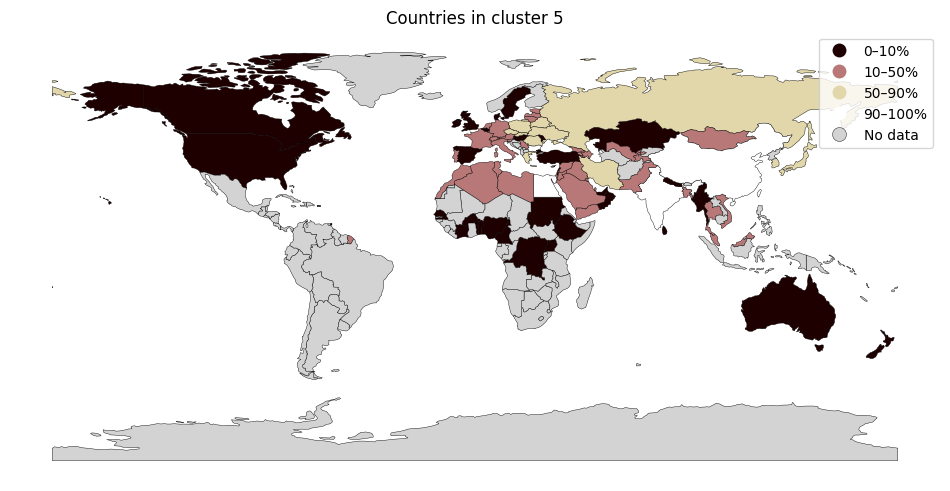

In [1726]:
# --- 4. Merge with world map ---
world = world_url.merge(
    df_cluster_country_count,
    left_on="ISO_A3_EH",
    right_on="alpha-3",
    how="left"
)

# --- 5. Plot ---
fig, ax = plt.subplots(figsize=(12, 6))

world.plot(
    column="year_cat",   # categorical column
    cmap="pink",            # automatically applied
    legend=True,               # clean legend
    edgecolor="black",
    linewidth=0.3,
    ax=ax,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    }
)

# --- 6. Styling ---
ax.set_axis_off()
ax.set_title(f"Countries in cluster {cluster}")

plt.show()

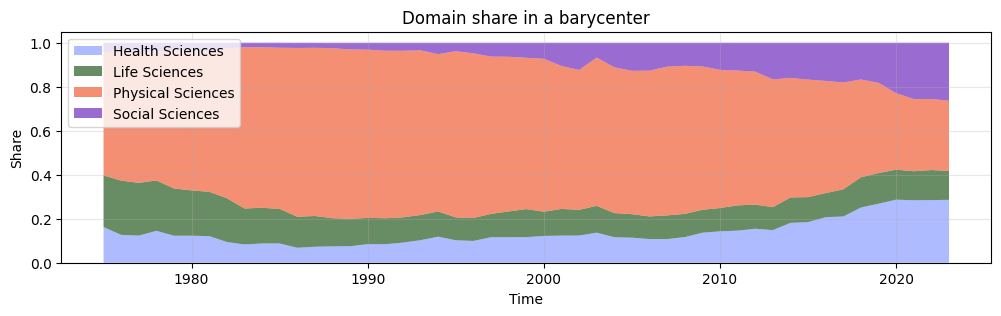

In [1727]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 3))

x = df_domains.index.astype(int)
y1 = df_domains[df_domains.columns[0]]
y2 = df_domains[df_domains.columns[1]]
y3 = df_domains[df_domains.columns[2]]
y4 = df_domains[df_domains.columns[3]]

ax.stackplot(x, y1, y2, y3, y4, labels=df_domains.columns, alpha=0.7, colors=[colors_domain[c] for c in df_domains.columns])

ax.legend(loc="upper left")
ax.set_ylabel("Share")
ax.set_xlabel("Time")
ax.set_title("Domain share in a barycenter")
plt.grid(alpha=0.3)

plt.show()

In [1728]:
# fig, ax = plt.subplots(figsize=(12, 3))
# plt.plot(df_gini_countries.index, df_gini_countries.cluster, label="Cluster")
# plt.plot(df_gini_countries.index, df_gini_countries["all"], label="Global")
# plt.grid(alpha=0.3)
# plt.ylabel("Gini")
# plt.legend()
# _ = plt.title("Gini coefficient by countries productivity")

In [1729]:
# fig, ax = plt.subplots(figsize=(12, 3))
# plt.plot(df_gini_profiles.index, df_gini_profiles.cluster, label="Cluster")
# plt.plot(df_gini_profiles.index, df_gini_profiles["all"], label="Global")
# plt.grid(alpha=0.3)
# plt.ylabel("Gini")
# plt.legend()
# _ = plt.title("Gini coefficient by subfield profiles")

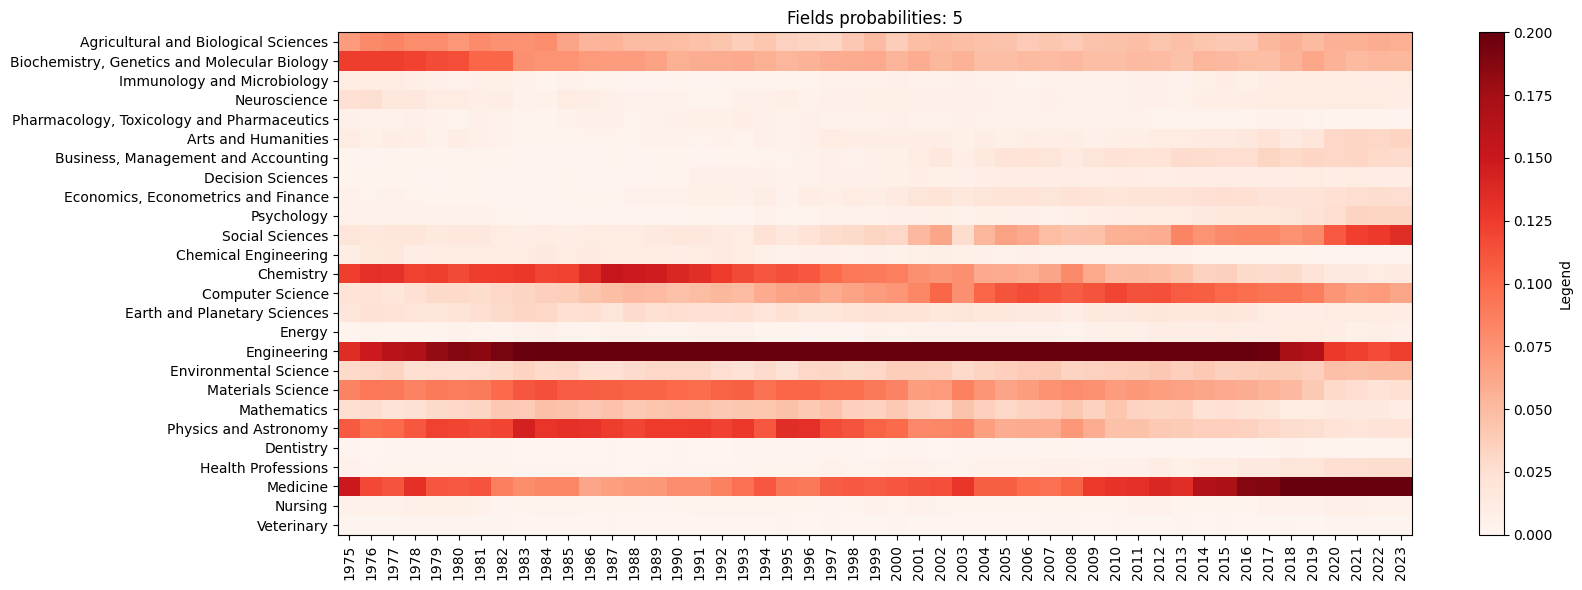

In [1730]:
df_plot = get_prob_fields(df_profile_yearly.xs(cluster))
uf.plot_heatmap(df_plot.T, df_plot.index, df_plot.columns, line_height=10,
                # x_type="subfield",
                z_min=0, z_max=0.2, colorscale="non", title=f"Fields probabilities: {cluster}")

In [1731]:
# uf.plotly_heatmap(
#     df_profile_yearly.xs(cluster),
#     x_labels=df_profile_yearly.xs(cluster).columns,
#     y_labels=df_profile_yearly.xs(cluster).index,
#     z_min=0,
#     z_max=0.02,
#     colorscale="non",
#     x_type="subfield"
# )

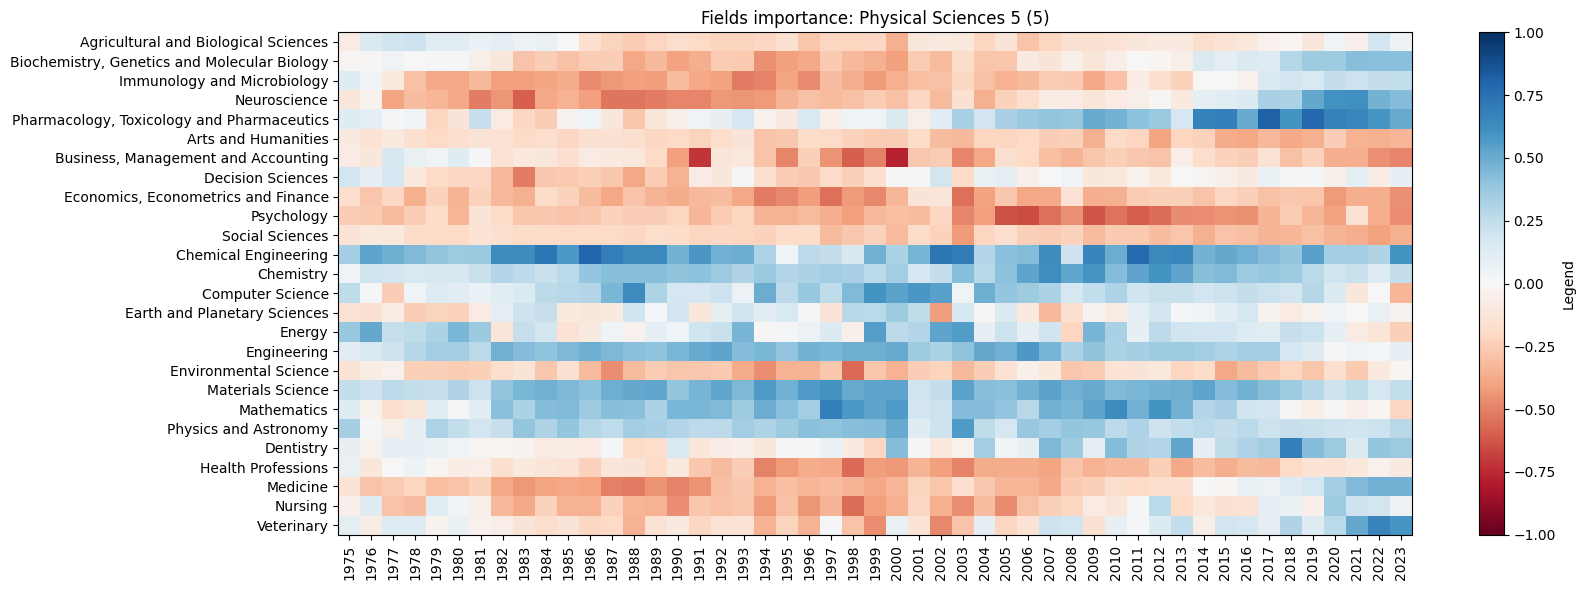

In [1732]:
uf.plot_heatmap(df_profile_norm_spec_fields_yearly.xs(cluster).T, df_profile_spec_fields_yearly.xs(cluster).index, df_profile_spec_fields_yearly.xs(cluster).columns, line_height=10,
                # x_type="subfield",
                z_min=-1, z_max=1, colorscale="symm", title=f"Fields importance: {names_dict_cluster[cluster]}")

In [1733]:
df_plot = df_dist_country_cluster.query("(cluster_dist == @cluster) and (in_cluster == 1)")
px.box(df_plot, x="year", y="value", title=f"Distance to barycenter in cluster {cluster}", hover_name="country")

In [1734]:
df_plot = (
    df_prob_yearly.fillna(0)
    .apply(uf.gini, axis=1)
    .to_frame("gini_country")
    .merge(df_map_analysis, left_index=True, right_on=["country", "year"])
)
px.box(df_plot.query("cluster == @cluster"), x="year", y="gini_country", hover_name="country", title=f"Gini by country in cluster {cluster}")

In [1735]:
df_plot = (
    df_cs_yearly
    .sum(axis=1)
    .to_frame("total")
    .query("total > 0")
    .assign(log_total=lambda df: np.log(df.total))
    .merge(df_map_analysis, left_index=True, right_on=["country", "year"])
)
px.box(df_plot.query("cluster == @cluster"), x="year", y="log_total", hover_name="country", title=f"Log total articles by country in cluster {cluster}")

# Country overview

In [1643]:
country = "US"

year_list = df_map_analysis.query("country == @country").year.drop_duplicates().sort_values().to_list()
country_clusters = df_map_analysis.query("country == @country").cluster.drop_duplicates().sort_values().to_list()

In [1644]:
df_profile_country = df_prob_yearly.xs(country, level=0).loc[year_list]

In [1645]:
uf.plotly_heatmap(df_profile_country, x_labels=df_profile_country.columns, y_labels=year_list, colorscale="non", z_min=0, z_max=0.02, line_height=10, title=country)

In [1646]:
df_gl = (
    df_baricenter_global_yearly
    .loc[year_list]
    .apply(uf.gini, axis=1)
    .to_frame("global")
)
df_cl = (
    df_map_analysis
    .query("country == @country")
    .merge(df_profile_yearly, left_on=["cluster", "year"], right_index=True, how="left")
    .drop(columns=["country", "cluster"])
    .set_index("year")
    .apply(uf.gini, axis=1)
    .to_frame("cluster")
)

df_c = (
    df_profile_country
    .apply(uf.gini, axis=1)
    .to_frame(country)
)

df_gini = pd.concat([df_gl, df_cl, df_c], axis=1)

In [1647]:
cluster_list = df_map_analysis.query("country == @country").cluster.drop_duplicates().to_list()
cluster_labels = dict(zip(cluster_list ,["Cluster "+str(cl) if cluster_list[cl-1] != 0 else "Undefined" for cl in range(1, len(cluster_list)+1)]))
cluster_colors = dict(zip(cluster_list, cmap(np.linspace(0, 1, len(cluster_labels)))))

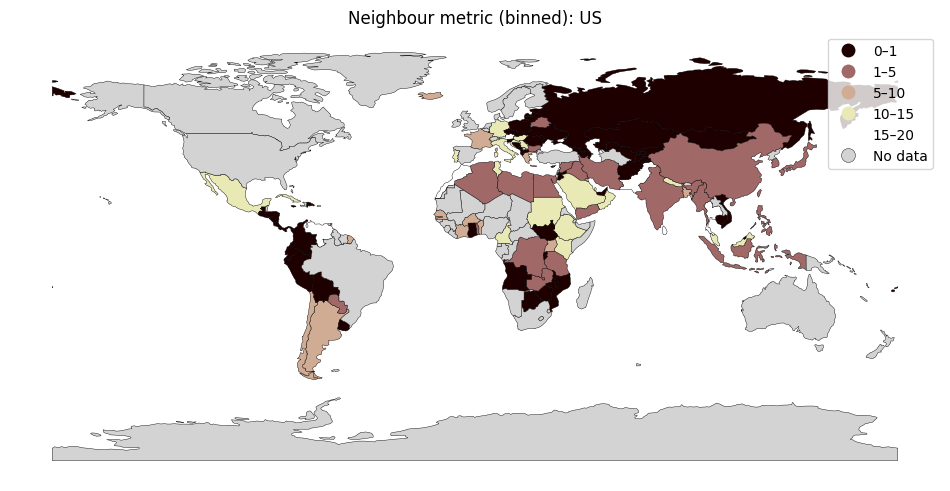

In [1648]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Define bins ---
bins = [0, 1, 5, 10, 15, 20]
labels = [f"{bins[i]}–{bins[i+1]}" for i in range(len(bins) - 1)]

# --- 2. Prepare data ---
df_plot_neighbours = (
    df_neighbours_counts
    .loc[country]
    .sort_values(ascending=False)
    .to_frame("years")
    .merge(
        uf.df_country[["alpha-2", "alpha-3"]],
        left_index=True,
        right_on="alpha-2",
        how="left"
    )
)

# --- 3. Create categorical variable ---
df_plot_neighbours["years_category"] = pd.cut(
    df_plot_neighbours["years"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# --- 4. Merge with world map ---
world = world_url.merge(
    df_plot_neighbours,
    left_on="ISO_A3_EH",
    right_on="alpha-3",
    how="left"
)

# --- 5. Plot ---
fig, ax = plt.subplots(figsize=(12, 6))

world.plot(
    column="years_category",   # categorical column
    cmap="pink",            # automatically applied
    legend=True,               # clean legend
    edgecolor="black",
    linewidth=0.3,
    ax=ax,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    }
)

# --- 6. Styling ---
ax.set_axis_off()
ax.set_title(f"Neighbour metric (binned): {country}")

plt.show()